# Display pair plots for correlated features by manually computing correlation coefficients, selecting highly correlated pairs dynamically, and plotting scatter plots with trendlines using low-level plotting functions.

In [1]:
import csv

with open("heart.csv", "r", encoding="utf-8") as file:

    reader = csv.reader(file)

    rows = list(reader)

columns = rows[0]
data = rows[1:]

print("Rows:", len(data))
print("Columns:", len(columns))

Rows: 918
Columns: 12


In [2]:
import matplotlib.pyplot as plt

# Numerical columns

In [3]:
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

print(numeric_columns)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


# Numerical data manually

In [4]:
numeric_data = {}

for column in numeric_columns:

    column_index = columns.index(column)

    values = []

    for row in data:

        value = row[column_index].strip()

        if value != "":
            values.append(float(value))

    numeric_data[column] = values

# Mean manually calculate

In [5]:
def calculate_mean(values):

    total = 0

    for value in values:
        total += value

    return total / len(values)

# Correlation manually calculate


In [6]:
def calculate_correlation(x, y):

    mean_x = calculate_mean(x)
    mean_y = calculate_mean(y)

    numerator = 0

    sum_x_squared = 0
    sum_y_squared = 0

    for i in range(len(x)):

        difference_x = x[i] - mean_x
        difference_y = y[i] - mean_y

        numerator += (
            difference_x * difference_y
        )

        sum_x_squared += (
            difference_x ** 2
        )

        sum_y_squared += (
            difference_y ** 2
        )

    denominator = (
        sum_x_squared *
        sum_y_squared
    ) ** 0.5

    if denominator == 0:
        return 0

    correlation = numerator / denominator

    return correlation

# columns test

In [7]:
x = numeric_data["Age"]
y = numeric_data["MaxHR"]

correlation = calculate_correlation(x, y)

print(
    "Age vs MaxHR:",
    correlation
)

Age vs MaxHR: -0.3820446750319703


In [8]:
correlations = []

for i in range(len(numeric_columns)):

    for j in range(i + 1, len(numeric_columns)):

        column_x = numeric_columns[i]
        column_y = numeric_columns[j]

        x = numeric_data[column_x]
        y = numeric_data[column_y]

        correlation = calculate_correlation(
            x,
            y
        )

        correlations.append(
            (
                column_x,
                column_y,
                correlation
            )
        )

In [9]:
for item in correlations:

    column_x = item[0]
    column_y = item[1]
    correlation = item[2]

    print(
        column_x,
        "vs",
        column_y,
        "=",
        round(correlation, 3)
    )

Age vs RestingBP = 0.254
Age vs Cholesterol = -0.095
Age vs FastingBS = 0.198
Age vs MaxHR = -0.382
Age vs Oldpeak = 0.259
Age vs HeartDisease = 0.282
RestingBP vs Cholesterol = 0.101
RestingBP vs FastingBS = 0.07
RestingBP vs MaxHR = -0.112
RestingBP vs Oldpeak = 0.165
RestingBP vs HeartDisease = 0.108
Cholesterol vs FastingBS = -0.261
Cholesterol vs MaxHR = 0.236
Cholesterol vs Oldpeak = 0.05
Cholesterol vs HeartDisease = -0.233
FastingBS vs MaxHR = -0.131
FastingBS vs Oldpeak = 0.053
FastingBS vs HeartDisease = 0.267
MaxHR vs Oldpeak = -0.161
MaxHR vs HeartDisease = -0.4
Oldpeak vs HeartDisease = 0.404


In [11]:
print("Highly Correlated Pairs")
print("-----------------------")

for item in highly_correlated_pairs:

    print(
        item[0],
        "vs",
        item[1],
        "->",
        round(item[2], 3)
    )

Highly Correlated Pairs
-----------------------


# Trendline in slope and intercept manually calculate

y=mx+b

In [20]:
threshold = 0.30

highly_correlated_pairs = []

for item in correlations:

    column_x = item[0]
    column_y = item[1]
    correlation = item[2]

    if abs(correlation) >= threshold:

        highly_correlated_pairs.append(
            (
                column_x,
                column_y,
                correlation
            )
        )

print("HIGHLY CORRELATED PAIRS")
print("=======================")

for item in highly_correlated_pairs:

    print(
        item[0],
        "vs",
        item[1],
        "=",
        round(item[2], 3)
    )

HIGHLY CORRELATED PAIRS
Age vs MaxHR = -0.382
MaxHR vs HeartDisease = -0.4
Oldpeak vs HeartDisease = 0.404


# Manual Trendline Function

In [21]:
def manual_trendline(x, y):

    mean_x = manual_mean(x)
    mean_y = manual_mean(y)

    numerator = 0
    denominator = 0

    for i in range(len(x)):

        numerator += (
            (x[i] - mean_x)
            *
            (y[i] - mean_y)
        )

        denominator += (
            (x[i] - mean_x) ** 2
        )

    if denominator == 0:

        return 0, mean_y

    slope = numerator / denominator

    intercept = (
        mean_y
        - slope * mean_x
    )

    return slope, intercept

In [23]:
def manual_mean(values):

    total = 0

    for value in values:
        total += value

    return total / len(values)

In [24]:
def manual_trendline(x, y):

    mean_x = manual_mean(x)
    mean_y = manual_mean(y)

    numerator = 0
    denominator = 0

    for i in range(len(x)):

        numerator += (
            (x[i] - mean_x) *
            (y[i] - mean_y)
        )

        denominator += (
            (x[i] - mean_x) ** 2
        )

    slope = numerator / denominator

    intercept = mean_y - slope * mean_x

    return slope, intercept

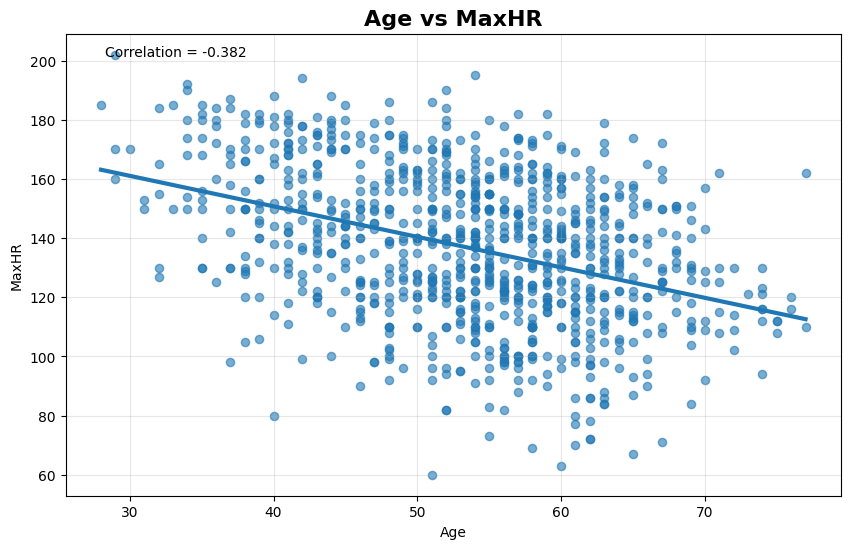

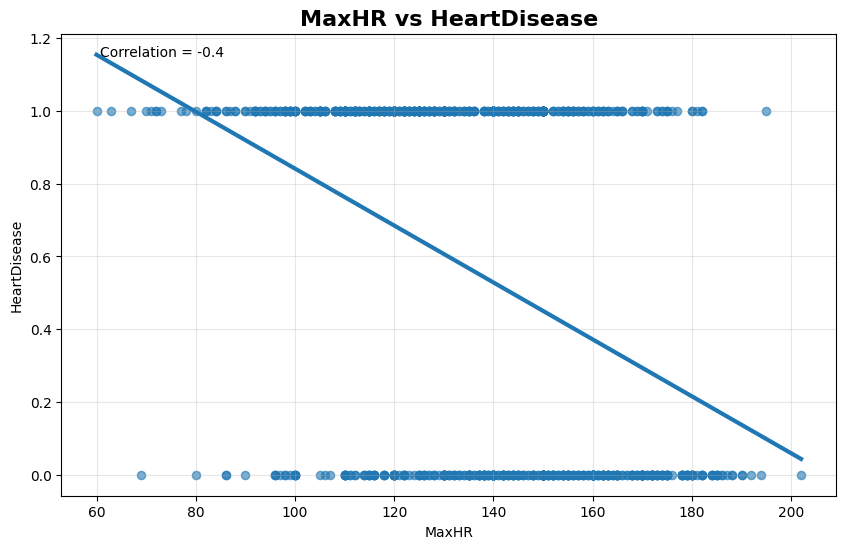

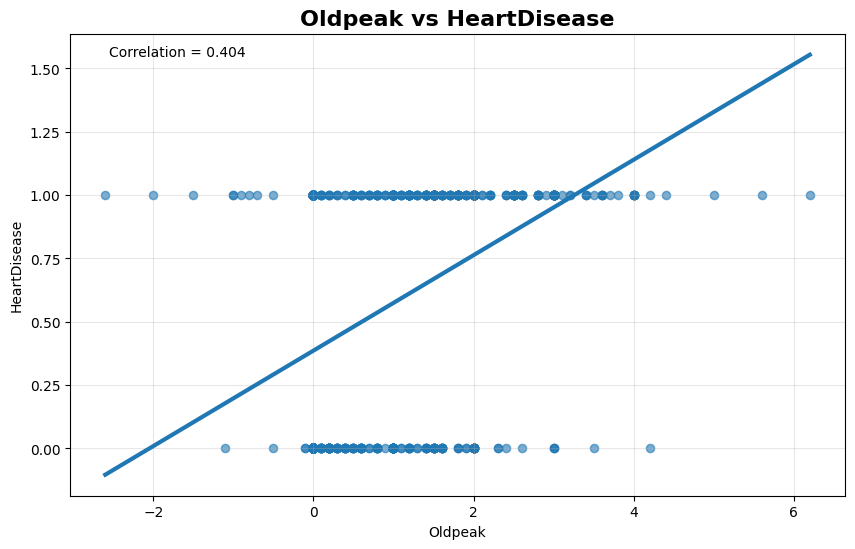

In [25]:
for item in highly_correlated_pairs:

    column_x = item[0]
    column_y = item[1]
    correlation = item[2]

    x = numeric_data[column_x]
    y = numeric_data[column_y]

    slope, intercept = manual_trendline(x, y)

    x_min = min(x)
    x_max = max(x)

    line_x = [x_min, x_max]

    line_y = [
        slope * x_min + intercept,
        slope * x_max + intercept
    ]

    plt.figure(figsize=(10,6))

    plt.scatter(x, y, s=35, alpha=0.6)

    plt.plot(line_x, line_y, linewidth=3)

    plt.title(column_x + " vs " + column_y,
              fontsize=16,
              fontweight="bold")

    plt.xlabel(column_x)
    plt.ylabel(column_y)

    plt.text(
        0.05,
        0.95,
        "Correlation = " + str(round(correlation,3)),
        transform=plt.gca().transAxes
    )

    plt.grid(alpha=0.3)

    plt.show()